In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import cm
from tqdm import tqdm
import os
from numpy import linalg as la
from numpy import *
from sklearn.model_selection import train_test_split


In [2]:
def ou_process_1d(theta=1, mu=0, sigma=1, X0=0, n_steps=10000, n_eval=200, h=1e-5):
    """
    Simulates the Ornstein-Uhlenbeck process.
    
    Parameters:
    - theta: rate of mean reversion
    - mu: long-term mean of the process
    - sigma: volatility
    - X0: initial value
    - n_steps: number of steps in each evaluation
    - n_eval: number of evaluations
    - h: Integration step size
    
    Returns:
    - A numpy array containing the simulated values at each evaluation
    """
    X_eval = np.zeros(n_eval)
    X = X0
    
    for i in range(n_eval):
        for _ in range(n_steps):
            dW = np.sqrt(h) * np.random.randn()
            X = X + theta * (mu - X) * h + sigma * dW
        X_eval[i] = X
    
    return X_eval

## Setup the parameters
theta = 1
mu = 0
sigma = 0.1

In [3]:
# Generate m initial points from the domain space [-2, 2]
m = 100
n_eval = 1
n_steps = 1000
h = 1e-5
lag_time = n_steps * h
print("lag time: ", lag_time)
X0_values = np.linspace(-2, 2, m)

# Initialize the data_matrix
data_matrix = np.zeros((m, n_eval+1, 1))

# Simulate trajectories for each initial point and store them in the data_matrix
for i, X0 in tqdm(enumerate(X0_values), total=m, desc="Simulating trajectories"):
    X_eval = np.concatenate(([X0], ou_process_1d(X0=X0, n_steps=n_steps, n_eval=n_eval, h=h)))
    data_matrix[i, :, 0] = X_eval

# Print the shape of data_matrix
print("Shape of data_matrix:", data_matrix.shape)

# Extract data_X and data_Y from the data matrix
data_X = data_matrix[:, :-1, :]
data_Y = data_matrix[:, 1:, :]
print(f"Shape of data_X: {data_X.shape}")
print(f"Shape of data_Y: {data_Y.shape}")

# Reshape data_X and data_Y into a single column
X = data_X.reshape(-1, data_X.shape[2])  # 2D features
Y = data_Y.reshape(-1, data_X.shape[2])  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]

print(X.shape)

lag time:  0.01


Simulating trajectories: 100%|██████████| 100/100 [00:00<00:00, 706.80it/s]

Shape of data_matrix: (100, 2, 1)
Shape of data_X: (100, 1, 1)
Shape of data_Y: (100, 1, 1)
Shape of X: (100, 1)
Shape of Y: (100, 1)
(100, 1)


In [ ]:
from itertools import product

def monomial_basis(x, degree=3):
    # x: (N, d)
    N, d = x.shape
    # Only keep monomials with total degree <= degree
    powers = [p for p in product(range(degree+1), repeat=d) if sum(p) <= degree]
    basis = np.empty((N, len(powers)))
    for i, p in enumerate(powers):
        basis[:, i] = np.prod(x**p, axis=1)
    return basis, powers

def monomial_derivatives(x, powers):
    N, d = x.shape
    basis_dx = np.zeros((N, len(powers), d))      # Jacobian: partial derivatives of each monomial w.r.t. each variable
    basis_ddx = np.zeros((N, len(powers), d))     # Hessian: second derivatives of each monomial w.r.t. each variable
    for i, p in enumerate(powers):
        for j in range(d):
            # First derivative
            if p[j] == 0:
                basis_dx[:, i, j] = 0
            else:
                p_dx = np.array(p)
                p_dx[j] -= 1
                basis_dx[:, i, j] = p[j] * np.prod(x**p_dx, axis=1)
            # Second derivative
            if p[j] < 2:
                basis_ddx[:, i, j] = 0
            else:
                p_ddx = np.array(p)
                p_ddx[j] -= 2
                basis_ddx[:, i, j] = p[j]*(p[j]-1) * np.prod(x**p_ddx, axis=1)
    return basis_dx, basis_ddx


degree = 5
delta_t = lag_time

# Construct Psi_X, powers
Psi_X, powers = monomial_basis(X, degree)

# Compute first and second derivatives
Psi_X_dx, Psi_X_ddx = monomial_derivatives(X, powers)

# Assume theta, mu, sigma are all vectors of shape (d,)
theta_vec = np.full(X.shape[1], theta) if np.isscalar(theta) else np.array(theta)
mu_vec = np.full(X.shape[1], mu) if np.isscalar(mu) else np.array(mu)
sigma_vec = np.full(X.shape[1], sigma) if np.isscalar(sigma) else np.array(sigma)

# Compute generator action
dPsi_X = np.zeros((X.shape[0], len(powers)))
for j in range(X.shape[1]):
    dPsi_X += theta_vec[j] * (mu_vec[j] - X[:, j:j+1]) * Psi_X_dx[:, :, j]
    dPsi_X += 0.5 * sigma_vec[j]**2 * Psi_X_ddx[:, :, j]

# Construct Psi_X, Psi_Y
Psi_X,_ = monomial_basis(X, degree)
Psi_Y,_ = monomial_basis(Y, degree)


G = Psi_X.T @ Psi_X
A = Psi_X.T @ Psi_Y
H = Psi_X.T @ dPsi_X

# EDMD: solve for K
K_EDMD = np.linalg.pinv(G) @ (A)

# EDMD: eigen decomposition
eigvals_EDMD, eigvecs_EDMD = np.linalg.eig(K_EDMD)

# Compute all eigenfunctions at all data points
eigenfuns_EDMD = Psi_X @ eigvecs_EDMD  # shape (N, n_basis)

# SDMD: solve for generator A_SDMD
K_SDMD = np.eye(Psi_X.shape[1]) + delta_t * np.linalg.pinv(G) @ (H)

# SDMD: eigen decomposition
eigvals_SDMD, eigvecs_SDMD = np.linalg.eig(K_SDMD)
# Compute all eigenfunctions at all data points
eigenfuns_SDMD = Psi_X @ eigvecs_SDMD  # shape (N, n_basis)

# gEDMD: solve for generator A
A = np.linalg.pinv(G) @ (H)

# gEDMD: eigen decomposition
eigvals_gEDMD, eigvecs_gEDMD = np.linalg.eig(A)
# Compute all eigenfunctions at all data points
eigenfuns_gEDMD = Psi_X @ eigvecs_gEDMD  # shape (N, n_basis)

In [5]:
print(Psi_X.shape)
print(dPsi_X.shape)
print(K_EDMD.shape)
print(K_SDMD.shape)
print(A.shape)

(100, 6)
(100, 6)
(6, 6)
(6, 6)
(6, 6)


[-1.68068598e+01 -2.09832152e-12  7.37269221e+00 -7.50809389e+00]


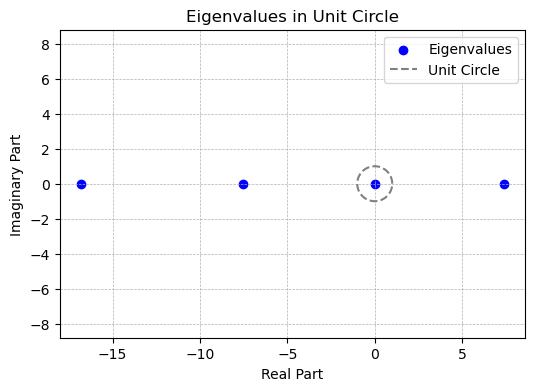

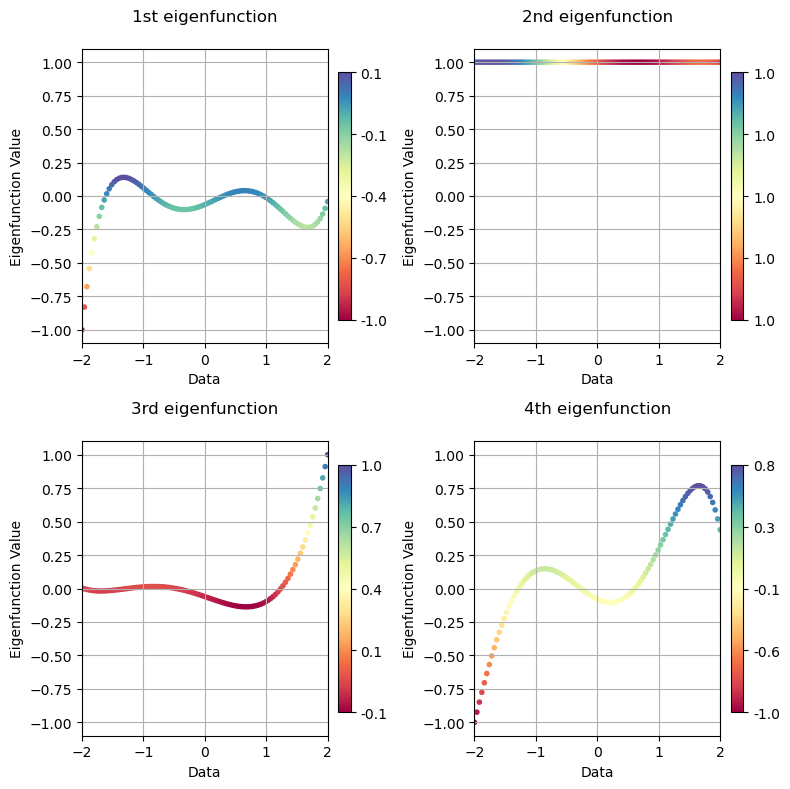

In [ ]:
## EDMD
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues_EDMD_leading = (eigvals_EDMD[:4]-1) / delta_t

print(ln_evalues_EDMD_leading)

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues_EDMD_leading.real
imag_parts = ln_evalues_EDMD_leading.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(eigenfuns_EDMD)

# Normalize each eigenfunction, colorbar only reflects the value distribution of the current eigenfunction
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    phi_i = np.real(eigenfuns_EDMD[:, i])
    phi_i = phi_i / np.max(np.abs(phi_i))  # Normalize individually
    vmin = np.min(phi_i)
    vmax = np.max(phi_i)
    cbar_ticks = np.linspace(vmin, vmax, 5)
    scatter = ax.scatter(X, phi_i, c=phi_i, cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.1, 1.1)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
plt.tight_layout()
plt.show()

[ 0. -1. -2. -3.]


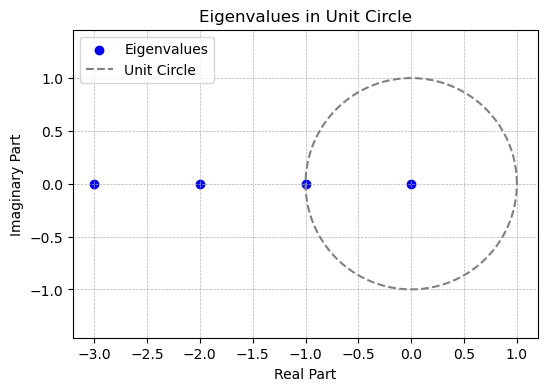

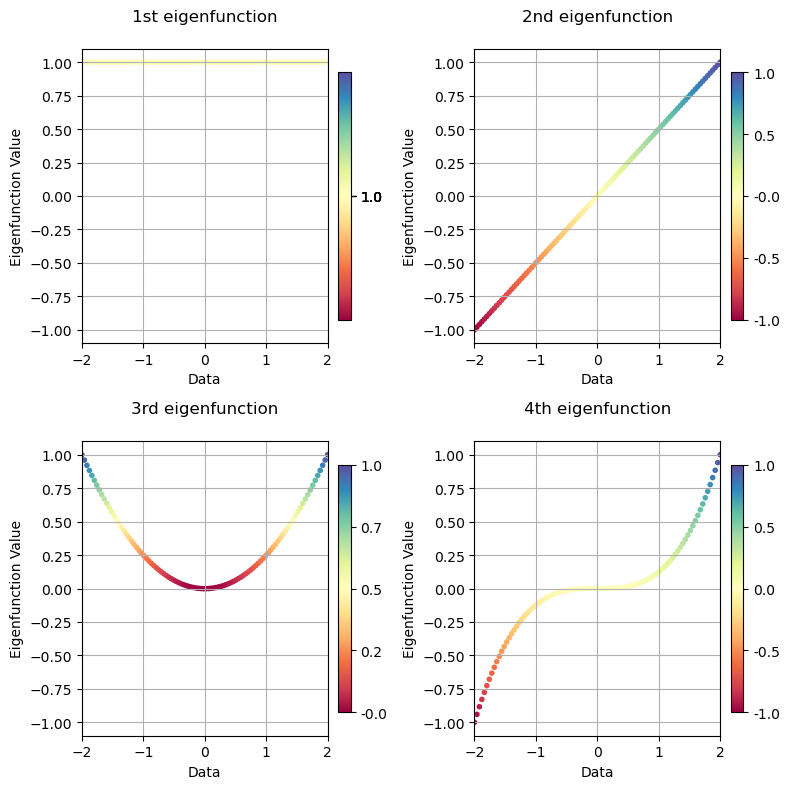

In [ ]:
## SDMD
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues_SDMD_leading = (eigvals_SDMD[:4]-1) / delta_t

print(ln_evalues_SDMD_leading)

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues_SDMD_leading.real
imag_parts = ln_evalues_SDMD_leading.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(eigenfuns_SDMD)

# Normalize each eigenfunction, colorbar only reflects the value distribution of the current eigenfunction
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    phi_i = np.real(eigenfuns_EDMD[:, i])
    phi_i = phi_i / np.max(np.abs(phi_i))  # Normalize individually
    vmin = np.min(phi_i)
    vmax = np.max(phi_i)
    cbar_ticks = np.linspace(vmin, vmax, 5)
    scatter = ax.scatter(X, phi_i, c=phi_i, cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.1, 1.1)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
plt.tight_layout()
plt.show()

[ 0. -1. -2. -3.]


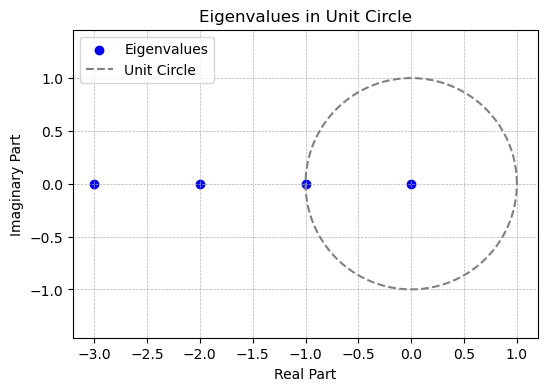

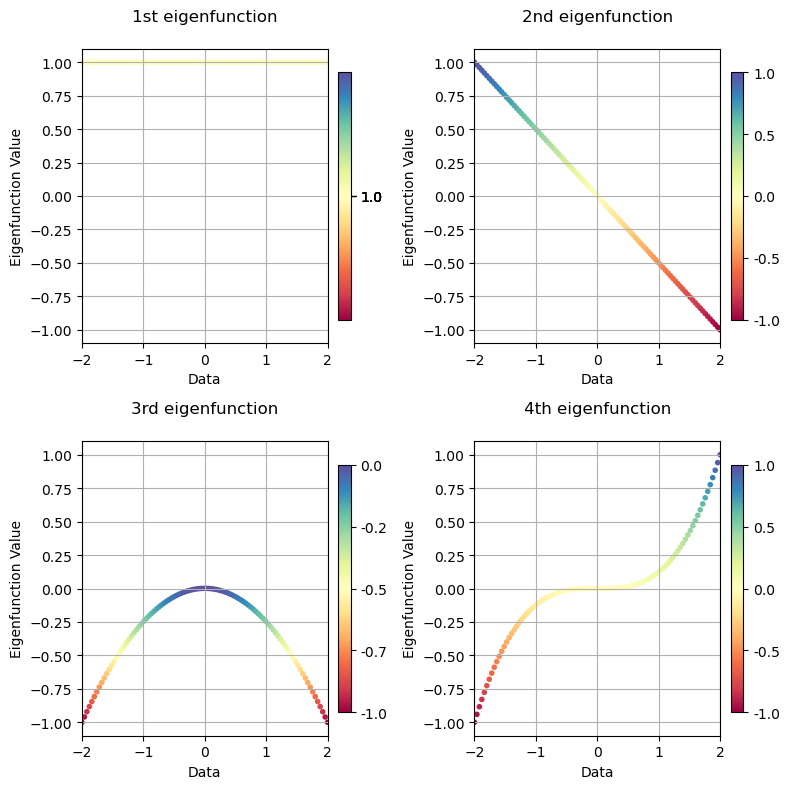

In [ ]:
## gEDMD
# ln_evalues = np.log(evalues[:4]) / lag_time
eigvals_gEDMD_leading = eigvals_gEDMD[:4]

print(eigvals_gEDMD_leading)

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = eigvals_gEDMD_leading.real
imag_parts = eigvals_gEDMD_leading.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(eigenfuns_gEDMD)

# Normalize each eigenfunction, colorbar only reflects the value distribution of the current eigenfunction
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    phi_i = np.real(eigenfuns_EDMD[:, i])
    phi_i = phi_i / np.max(np.abs(phi_i))  # Normalize individually
    vmin = np.min(phi_i)
    vmax = np.max(phi_i)
    cbar_ticks = np.linspace(vmin, vmax, 5)
    scatter = ax.scatter(X, phi_i, c=phi_i, cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.1, 1.1)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Show the values of the first few eigenfunctions for the first few data points
print("efuns (first 5 points, first 4 eigenfunctions):")
print(eigenfuns_gEDMD[:5, :4])

efuns (first 5 points, first 4 eigenfunctions):
[[ 1.          1.         -1.         -1.        ]
 [ 1.          0.97979798 -0.95995402 -0.94046255]
 [ 1.          0.95959596 -0.92072531 -0.88333339]
 [ 1.          0.93939394 -0.88231387 -0.82856287]
 [ 1.          0.91919192 -0.84471968 -0.77610133]]
